# Modelo Causal Final — TCC
## Estimativa de Efeitos Causais na Jornada de Compra de um Marketplace
---

### Pergunta de pesquisa
> *"Como modelar e estimar os efeitos causais de variáveis observáveis da jornada do pedido em um marketplace sobre as avaliações dos consumidores?"*

### Variáveis causais
| Papel | Variável | Definição |
|---|---|---|
| **Tratamento (T)** | `is_delayed` | 1 se entregue após a data estimada; 0 caso contrário |
| **Outcome (Y)** | `review_score_outcome` | 1 = avaliação neutra/positiva (3–5); 0 = negativa (1–2) |
| **Confundidores (Z)** | 17 variáveis | Carregadas do `features.yaml` |

### Estrutura do notebook
| Seção | Conteúdo |
|---|---|
| 1 | Imports e configuração |
| 2 | DAG — Grafo Causal e critério de backdoor |
| 3 | Confundidores — análise de desequilíbrio bruto |
| 4 | Propensity Score — estimação e diagnóstico |
| 5 | IPTW — ponderação e balanço de covariáveis |
| 6 | ATE — Efeito Médio do Tratamento + Bootstrap IC 95% |
| 7 | RDD — Regressão com Descontinuidade |
| 8 | Triangulação IPTW vs. RDD |
| 9 | Interpretação e resposta à pergunta de pesquisa |

## 1. Imports e Configuração

In [51]:
import os
import warnings
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import statsmodels.api as sm

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

from app.config.settings import INTERIM_DATA_DIR, PROJECT_DIR
from app.data import get_features
from app.data.utils import find_specific_variables

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

FIGURES_DIR = PROJECT_DIR / 'reports' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print('Imports OK')
print(f'Figuras serão salvas em: {FIGURES_DIR}')

Imports OK
Figuras serão salvas em: /Users/andreza/Documents/GitHub/TCC-CEDS-CAUSAL-AI/reports/figures


## 2. Variáveis do Modelo

**Contexto:** Os 17 confundidores representam variáveis operacionais da jornada do pedido que afetam simultaneamente a probabilidade de atraso (T) e a avaliação do cliente (Y).

In [52]:
features    = get_features('features.yaml')
treatment   = find_specific_variables(features, 'treatment',  specific_value=True)[0]
outcome     = find_specific_variables(features, 'outcome',    specific_value=True)[0]
confounders = find_specific_variables(features, 'confounder', specific_value=True)

# Grupos semânticos para visualização no DAG
CONF_PRECO = ['total_price', 'avg_price', 'total_payment', 'avg_payment', 'installment_value']
CONF_FRETE = ['total_freight', 'avg_freight']
CONF_COMPL = ['n_items', 'n_items_missing_info', 'n_item_distinct_categ', 'n_payment']
CONF_DIMS  = ['avg_weight', 'avg_lenght', 'avg_height', 'avg_width']
CONF_TEMP  = ['purchase_weekday', 'purchase_month']
CONF_ORDER = CONF_PRECO + CONF_FRETE + CONF_COMPL + CONF_DIMS + CONF_TEMP

print(f'Treatment   : {treatment}')
print(f'Outcome     : {outcome}')
print(f'Confundidores ({len(confounders)}):')
for g, nome in [('Preço/Valor', CONF_PRECO), ('Frete', CONF_FRETE),
                ('Complexidade', CONF_COMPL), ('Dimensões', CONF_DIMS),
                ('Temporal', CONF_TEMP)]:
    print(f'  {g:15}: {nome}')

Treatment   : is_delayed
Outcome     : review_score_outcome
Confundidores (17):
  Preço/Valor    : ['total_price', 'avg_price', 'total_payment', 'avg_payment', 'installment_value']
  Frete          : ['total_freight', 'avg_freight']
  Complexidade   : ['n_items', 'n_items_missing_info', 'n_item_distinct_categ', 'n_payment']
  Dimensões      : ['avg_weight', 'avg_lenght', 'avg_height', 'avg_width']
  Temporal       : ['purchase_weekday', 'purchase_month']


## 3. DAG — Grafo Causal Dirigido

**O que:** Formaliza as suposições causais por meio de um Directed Acyclic Graph (DAG).  
O DAG é a fundamentação teórica que transforma o IPTW de técnica estatística em estimativa causal. Ele declara explicitamente que os 17 confundidores afetam tanto T quanto Y, e que não existe caminho direto de Y para T (aciclidicidade).  

**Critério de backdoor:** Um conjunto S satisfaz o backdoor se (1) nenhum elemento de S é descendente de T e (2) S bloqueia todos os caminhos espúrios entre T e Y. Verificado formalmente via DoWhy.  

**Contexto:** Sem o DAG, o IPTW é apenas uma reponderação estatística. Com o DAG, ele estima um efeito causal identificável.

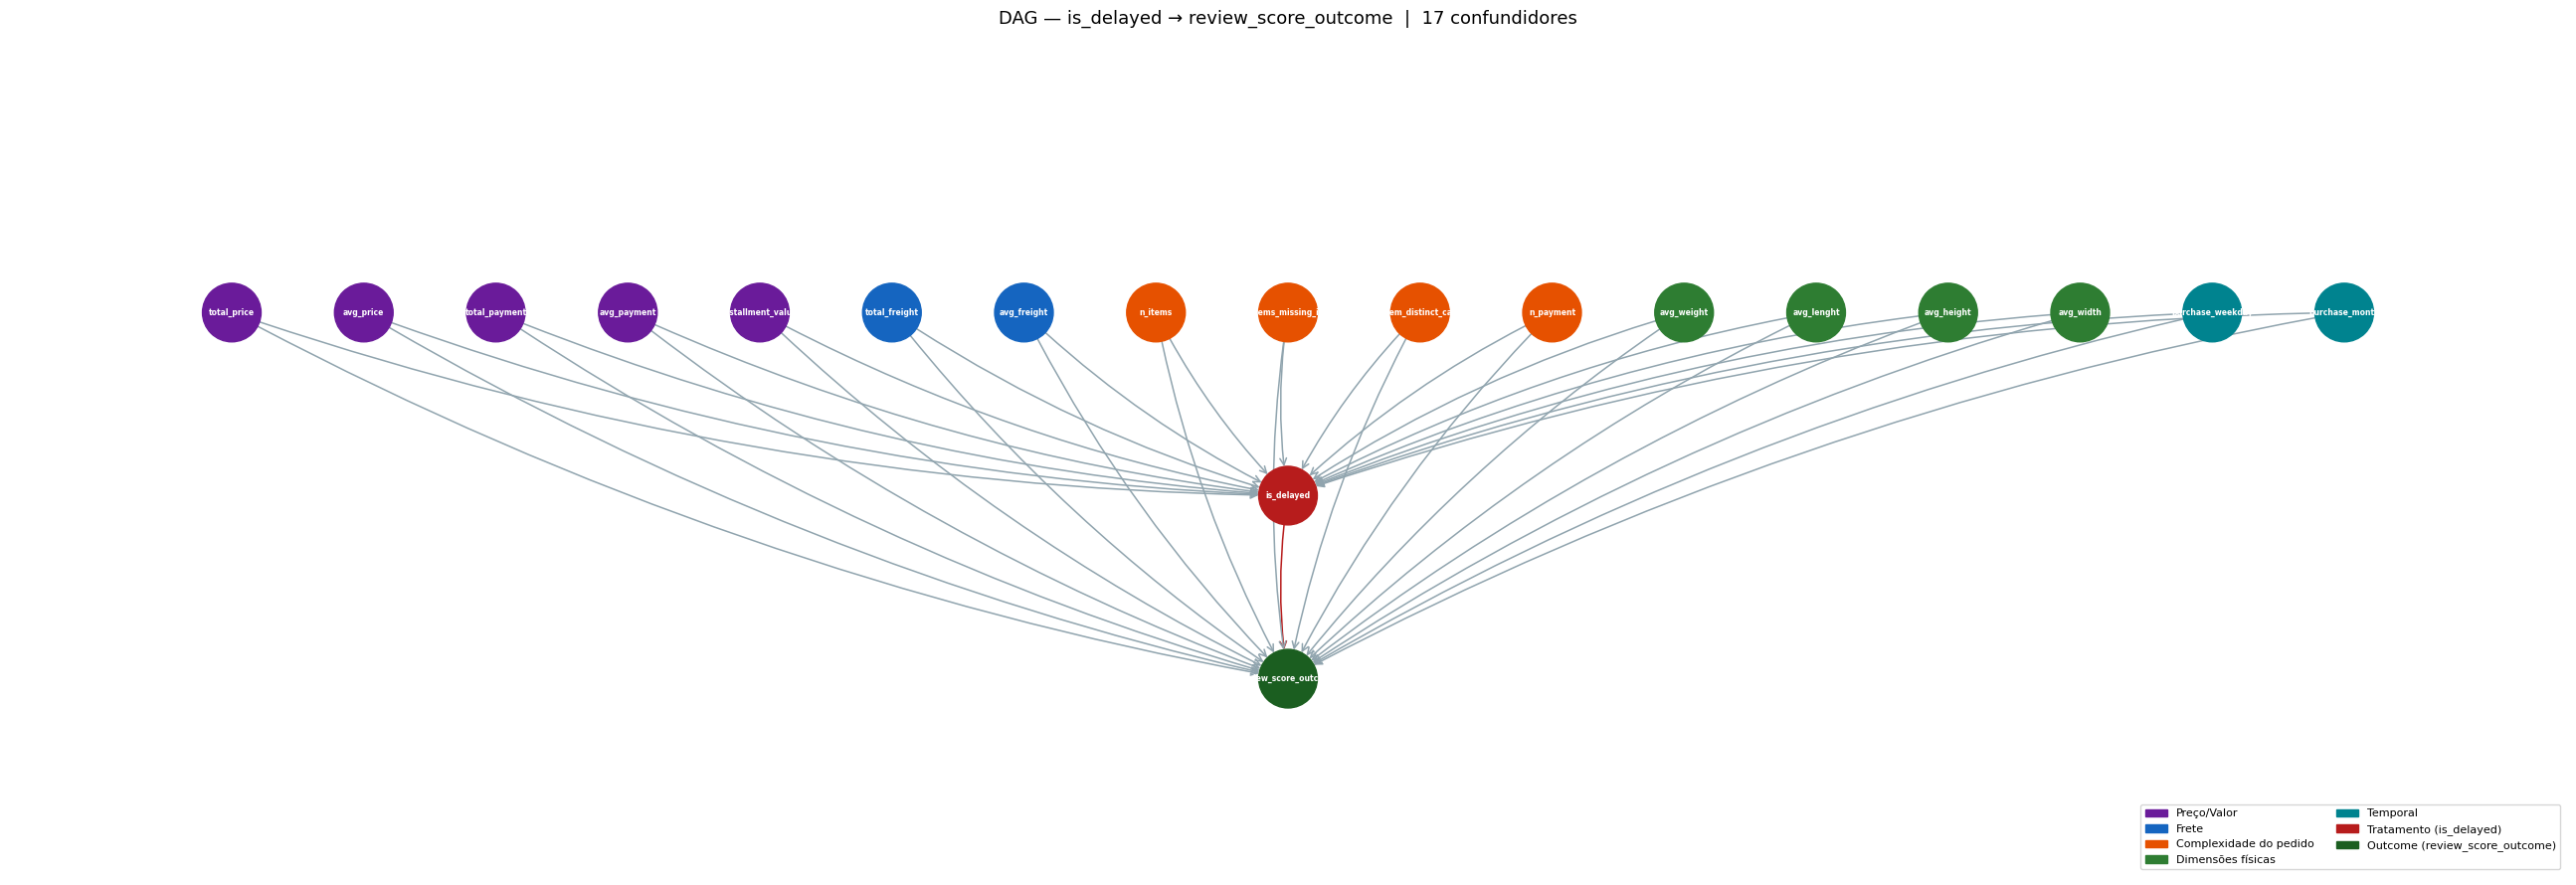

Figura salva: dag_final_geral.png


In [53]:
GRUPO_CORES = {
    **{v: '#6a1b9a' for v in CONF_PRECO},
    **{v: '#1565c0' for v in CONF_FRETE},
    **{v: '#e65100' for v in CONF_COMPL},
    **{v: '#2e7d32' for v in CONF_DIMS},
    **{v: '#00838f' for v in CONF_TEMP},
}

ARESTAS_DAG = ([(c, treatment) for c in confounders] +
               [(c, outcome)   for c in confounders] +
               [(treatment, outcome)])

G = nx.DiGraph()
G.add_edges_from(ARESTAS_DAG)

pos = {}
for i, c in enumerate(CONF_ORDER):
    pos[c] = (i * 1.85, 2)
x_c = (len(CONF_ORDER) - 1) * 1.85 / 2
pos[treatment] = (x_c, 1)
pos[outcome]   = (x_c, 0)

cor_map = {n: GRUPO_CORES.get(n, '#455a64') for n in G.nodes()}
cor_map[treatment] = '#b71c1c'
cor_map[outcome]   = '#1b5e20'
cores = [cor_map[n] for n in G.nodes()]
edge_colors = ['#b71c1c' if u == treatment else '#90a4ae' for u, v in G.edges()]

fig, ax = plt.subplots(figsize=(26, 9))
nx.draw_networkx(G, pos=pos, ax=ax, node_color=cores, node_size=1800,
                 font_size=5.5, font_color='white', font_weight='bold',
                 edge_color=edge_colors, arrows=True, arrowsize=12,
                 arrowstyle='->', connectionstyle='arc3,rad=0.08', width=1.1)

patches = [
    mpatches.Patch(color='#6a1b9a', label='Preço/Valor'),
    mpatches.Patch(color='#1565c0', label='Frete'),
    mpatches.Patch(color='#e65100', label='Complexidade do pedido'),
    mpatches.Patch(color='#2e7d32', label='Dimensões físicas'),
    mpatches.Patch(color='#00838f', label='Temporal'),
    mpatches.Patch(color='#b71c1c', label=f'Tratamento ({treatment})'),
    mpatches.Patch(color='#1b5e20', label=f'Outcome ({outcome})'),
]
ax.legend(handles=patches, loc='lower right', fontsize=8, ncol=2)
ax.set_title(f'DAG — {treatment} → {outcome}  |  {len(confounders)} confundidores', fontsize=13, pad=15)
ax.axis('off')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'dag_final_geral.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print('Figura salva: dag_final_geral.png')

In [54]:
# Verificação formal do critério de backdoor via NetworkX
descendants_T = sorted(nx.descendants(G, treatment))
any_conf_descendant = any(c in descendants_T for c in confounders)

print(f'DAG acíclico            : {nx.is_directed_acyclic_graph(G)}')
print(f'Nós                     : {G.number_of_nodes()}')
print(f'Arestas                 : {G.number_of_edges()}')
print(f'Descendentes de T       : {descendants_T}')
print(f'Confundidor é descendente de T? : {any_conf_descendant}')
print(f'→ Critério de backdoor  : {"SATISFEITO" if not any_conf_descendant else "VIOLADO"}')

DAG acíclico            : True
Nós                     : 19
Arestas                 : 35
Descendentes de T       : ['review_score_outcome']
Confundidor é descendente de T? : False
→ Critério de backdoor  : SATISFEITO


In [55]:
# Formalização via DoWhy — confirma identificabilidade do ATE
import dowhy
from dowhy import CausalModel

def build_gml(treatment, outcome, confounders):
    nos     = set(confounders + [treatment, outcome])
    arestas = ([(c, treatment) for c in confounders] +
               [(c, outcome)   for c in confounders] +
               [(treatment, outcome)])
    lines = ['graph [directed 1']
    for no in nos:
        lines.append(f'  node [ id "{no}" label "{no}" ]')
    for u, v in arestas:
        lines.append(f'  edge [ source "{u}" target "{v}" ]')
    lines.append(']')
    return '\n'.join(lines)

print('DoWhy carregado. Modelo será instanciado na seção 6 após o carregamento dos dados.')
print('GML builder definido.')

DoWhy carregado. Modelo será instanciado na seção 6 após o carregamento dos dados.
GML builder definido.


In [56]:
# ── RESUMO DA SEÇÃO 3 
print('=' * 60)
print('RESUMO — DAG')
print('=' * 60)
print(f'  Tratamento           : {treatment}')
print(f'  Outcome              : {outcome}')
print(f'  Total confundidores  : {len(confounders)}')
print(f'  Total arestas        : {G.number_of_edges()} ({len(confounders)} conf→T + {len(confounders)} conf→Y + 1 T→Y)')
print(f'  DAG acíclico         : {nx.is_directed_acyclic_graph(G)}')
print(f'  Critério de backdoor : {"SATISFEITO" if not any_conf_descendant else "VIOLADO"}')
print()
print('  → O DAG formaliza que o ATE de is_delayed sobre review_score_outcome')
print('    é identificável via backdoor adjustment nos 17 confundidores.')

RESUMO — DAG
  Tratamento           : is_delayed
  Outcome              : review_score_outcome
  Total confundidores  : 17
  Total arestas        : 35 (17 conf→T + 17 conf→Y + 1 T→Y)
  DAG acíclico         : True
  Critério de backdoor : SATISFEITO

  → O DAG formaliza que o ATE de is_delayed sobre review_score_outcome
    é identificável via backdoor adjustment nos 17 confundidores.


## 4. Confundidores — Análise de Desequilíbrio Bruto

**O que:** Compara as médias dos confundidores entre pedidos atrasados (T=1) e no prazo (T=0) antes do ajuste causal.  
 Demonstra que os grupos não são comparáveis — validando a necessidade do IPTW.  
**Pergunta que respondemos aqui:**
- *Pedidos atrasados diferem dos no prazo em características observáveis?*
- *Quais confundidores apresentam maior desequilíbrio bruto (SMD > 0.1)?*  

**Contexto :** O SMD (Standardized Mean Difference) é a métrica padrão para avaliar desequilíbrio. SMD > 0.1 indica que a variável distingue os grupos e precisa ser controlada.

In [57]:
cols_model = available_conf + [treatment, outcome]
df_model   = df[cols_model].dropna().copy()

T = df_model[treatment].values

def smd_raw(df_m, treatment, confounders):
    T = df_m[treatment].values
    result = {}
    for col in confounders:
        x = df_m[col].values.astype(float)
        m1, v1 = x[T==1].mean(), x[T==1].var()
        m0, v0 = x[T==0].mean(), x[T==0].var()
        pooled = np.sqrt((v1 + v0) / 2)
        result[col] = abs(m1 - m0) / pooled if pooled > 0 else 0.0
    return pd.Series(result)

smd_antes = smd_raw(df_model, treatment, available_conf)

df_bruto = pd.DataFrame({
    'Média T=1': df_model.groupby(treatment)[available_conf].mean().loc[1].round(3),
    'Média T=0': df_model.groupby(treatment)[available_conf].mean().loc[0].round(3),
    'SMD bruto':  smd_antes.round(4),
    'Desequilíbrio': smd_antes.apply(lambda x: 'SIM' if x > 0.1 else 'não')
})
df_bruto = df_bruto.sort_values('SMD bruto', ascending=False)
print(f'Desequilíbrio (SMD > 0.1): {(smd_antes > 0.1).sum()} de {len(available_conf)} confundidores')
df_bruto

Desequilíbrio (SMD > 0.1): 3 de 15 confundidores


,Média T=1,Média T=0,SMD bruto,Desequilíbrio
avg_freight,22.9360,19.9430,0.1758,SIM
purchase_month,5.6650,6.0570,0.1151,SIM
total_freight,25.1560,22.5930,0.1142,SIM
avg_weight,2455.4660,2069.5010,0.0951,não
avg_price,140.7080,123.9230,0.0849,não
avg_payment,171.9300,155.9050,0.0729,não
total_payment,174.5830,158.5220,0.0724,não
n_item_distinct_categ,1.0920,1.1280,0.0673,não
n_items,1.1100,1.1440,0.0646,não
total_price,149.4090,135.8990,0.0639,não


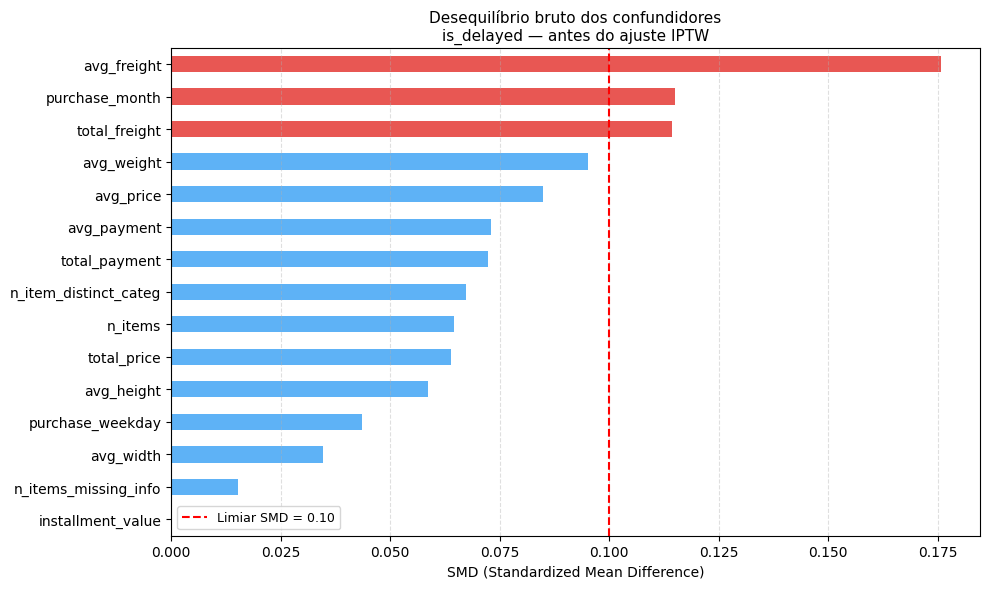

Figura salva: smd_bruto.png


In [58]:
fig, ax = plt.subplots(figsize=(10, 6))
cores_barra = ['#e53935' if v > 0.1 else '#42a5f5' for v in smd_antes.sort_values().values]
smd_antes.sort_values().plot(kind='barh', ax=ax, color=cores_barra, alpha=0.85)
ax.axvline(0.1, color='red', linestyle='--', linewidth=1.5, label='Limiar SMD = 0.10')
ax.set_xlabel('SMD (Standardized Mean Difference)')
ax.set_title(f'Desequilíbrio bruto dos confundidores\n{treatment} — antes do ajuste IPTW', fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'smd_bruto.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print('Figura salva: smd_bruto.png')

In [59]:
# ── RESUMO DA SEÇÃO 5 (insumo para interpretação) ──────────────────────────
n_desbal = (smd_antes > 0.1).sum()
top3 = smd_antes.nlargest(3)
print('=' * 60)
print('RESUMO — CONFUNDIDORES (desequilíbrio bruto)')
print('=' * 60)
print(f'  Confundidores com SMD > 0.1 : {n_desbal} de {len(available_conf)}')
print(f'  Top 3 mais desequilibrados  :')
for var, val in top3.items():
    print(f'    {var:<30} SMD = {val:.4f}')
print()
print('  → Os grupos T=1 e T=0 diferem em características observáveis,')
print('    justificando o uso do IPTW para criar grupos comparáveis.')

RESUMO — CONFUNDIDORES (desequilíbrio bruto)
  Confundidores com SMD > 0.1 : 3 de 15
  Top 3 mais desequilibrados  :
    avg_freight                    SMD = 0.1758
    purchase_month                 SMD = 0.1151
    total_freight                  SMD = 0.1142

  → Os grupos T=1 e T=0 diferem em características observáveis,
    justificando o uso do IPTW para criar grupos comparáveis.


## 5. Propensity Score — Estimação e Diagnóstico

**O que:** Estima a probabilidade de cada pedido ser atrasado dado seus confundidores: e(X) = P(T=1 | X).  
O propensity score resume toda a informação dos confundidores em um único número — a probabilidade de tratamento. O IPTW usa esse score para reponderar as observações.  

**Modelo:** Regressão logística com StandardScaler nas variáveis contínuas.  
**Diagnóstico:** AUC-ROC mede quão bem os confundidores separam os grupos. AUC muito próxima de 1 indica separação perfeita (problema); AUC entre 0.55–0.75 é ideal.  

**Contexto :** O DoWhy confirma formalmente que o ATE é identificável via backdoor adjustment antes da estimação.

In [60]:
# Pré-processamento: escalonamento das variáveis contínuas
df_ps = df_model.replace([np.inf, -np.inf], np.nan).dropna().copy()
scaler = StandardScaler()
df_ps[available_conf] = scaler.fit_transform(df_ps[available_conf])

X = df_ps[available_conf].values
T_vec = df_ps[treatment].values

clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X, T_vec)
ps = clf.predict_proba(X)[:, 1]
ps = np.clip(ps, 0.01, 0.99)

auc = roc_auc_score(T_vec, ps)

print(f'N no modelo           : {len(df_ps):,}')
print(f'AUC-ROC               : {auc:.4f}')
print(f'PS — média            : {ps.mean():.4f}')
print(f'PS — min / max        : {ps.min():.4f} / {ps.max():.4f}')
print(f'PS em T=1 — média     : {ps[T_vec==1].mean():.4f}')
print(f'PS em T=0 — média     : {ps[T_vec==0].mean():.4f}')

N no modelo           : 95,813
AUC-ROC               : 0.5720
PS — média            : 0.0666
PS — min / max        : 0.0100 / 0.7416
PS em T=1 — média     : 0.0698
PS em T=0 — média     : 0.0664


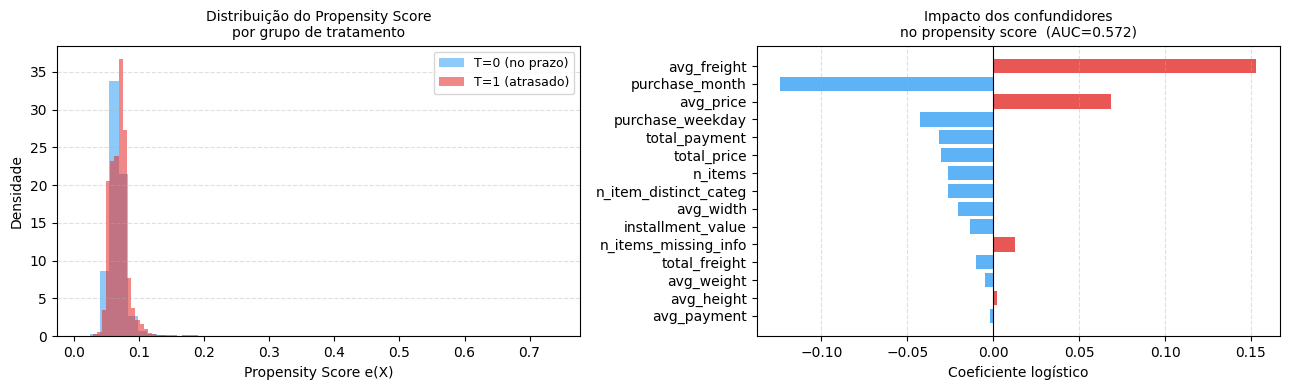

Figura salva: propensity_score.png


In [61]:
# Distribuição do propensity score por grupo
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(ps[T_vec==0], bins=50, alpha=0.6, color='#42a5f5', label='T=0 (no prazo)', density=True)
axes[0].hist(ps[T_vec==1], bins=50, alpha=0.6, color='#e53935', label='T=1 (atrasado)', density=True)
axes[0].set_xlabel('Propensity Score e(X)')
axes[0].set_ylabel('Densidade')
axes[0].set_title('Distribuição do Propensity Score\npor grupo de tratamento', fontsize=10)
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

# Coeficientes do modelo logístico
coef_df = pd.DataFrame({'Variável': available_conf, 'Coeficiente': clf.coef_[0]})
coef_df = coef_df.reindex(coef_df['Coeficiente'].abs().sort_values(ascending=True).index)
cores_coef = ['#e53935' if c > 0 else '#42a5f5' for c in coef_df['Coeficiente']]
axes[1].barh(coef_df['Variável'], coef_df['Coeficiente'], color=cores_coef, alpha=0.85)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Coeficiente logístico')
axes[1].set_title(f'Impacto dos confundidores\nno propensity score  (AUC={auc:.3f})', fontsize=10)
axes[1].grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'propensity_score.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print('Figura salva: propensity_score.png')

In [62]:
# DoWhy — confirmação formal da identificabilidade do ATE
gml   = build_gml(treatment, outcome, available_conf)
causal_model = CausalModel(data=df_model, treatment=treatment,
                            outcome=outcome, graph=gml)
identified = causal_model.identify_effect(proceed_when_unidentifiable=True)

 # Exibe apenas o resumo relevante
estimand_backdoor = identified.get_backdoor_variables()                                                                                                                                                                     
estimand_type     = str(identified.estimand_type).split('.')[-1]                                                                                                                                                            
                                                                                                                                                                                                                              
print('=' * 60)                                                                                                                                                                                                             
print('DoWhy — Identificação do efeito causal')                                                                                                                                                                             
print('=' * 60) 
print(f'  Tipo de estimando      : {estimand_type}')
print(f'  Método identificado    : Backdoor adjustment')                                                                                                                                                                    
print(f'  Conjunto de ajuste     : {len(estimand_backdoor)} variáveis')                                                                                                                                                     
for v in sorted(estimand_backdoor):                                                                                                                                                                                         
    print(f'    - {v}')                                                                                                                                                                                                     
print()                                                                                                                                                                                                                     
print('  Suposição de Unconfoundedness:')
print(f'  Não existe variável latente U que afete simultaneamente')                                                                                                                                                         
print(f'  {treatment} e {outcome} além dos confundidores observados.')                                                                                                                                                      
print()                                                                                                                                                                                                                     
print('  → ATE identificável via backdoor adjustment. ✓')                                                                                                                                                                   
                                                               

DoWhy — Identificação do efeito causal
  Tipo de estimando      : NONPARAMETRIC_ATE
  Método identificado    : Backdoor adjustment
  Conjunto de ajuste     : 15 variáveis
    - avg_freight
    - avg_height
    - avg_payment
    - avg_price
    - avg_weight
    - avg_width
    - installment_value
    - n_item_distinct_categ
    - n_items
    - n_items_missing_info
    - purchase_month
    - purchase_weekday
    - total_freight
    - total_payment
    - total_price

  Suposição de Unconfoundedness:
  Não existe variável latente U que afete simultaneamente
  is_delayed e review_score_outcome além dos confundidores observados.

  → ATE identificável via backdoor adjustment. ✓


In [63]:
# ── RESUMO DA SEÇÃO 6 (insumo para interpretação) ──────────────────────────
top3_coef = coef_df.reindex(coef_df['Coeficiente'].abs().sort_values(ascending=False).index).head(3)
print('=' * 60)
print('RESUMO — PROPENSITY SCORE')
print('=' * 60)
print(f'  Modelo            : Regressão Logística')
print(f'  AUC-ROC           : {auc:.4f}')
print(f'  Interpretação AUC : {"Boa separação" if 0.55 < auc < 0.80 else "Verificar"}')
print(f'  PS médio T=1      : {ps[T_vec==1].mean():.4f}')
print(f'  PS médio T=0      : {ps[T_vec==0].mean():.4f}')
print(f'  Top 3 confundidores com maior impacto no PS:')
for _, row in top3_coef.iterrows():
    print(f'    {row["Variável"]:<30} coef = {row["Coeficiente"]:+.4f}')
print(f'  DoWhy             : ATE identificável via backdoor adjustment')

RESUMO — PROPENSITY SCORE
  Modelo            : Regressão Logística
  AUC-ROC           : 0.5720
  Interpretação AUC : Boa separação
  PS médio T=1      : 0.0698
  PS médio T=0      : 0.0664
  Top 3 confundidores com maior impacto no PS:
    avg_freight                    coef = +0.1531
    purchase_month                 coef = -0.1240
    avg_price                      coef = +0.0686
  DoWhy             : ATE identificável via backdoor adjustment


## 6. IPTW — Ponderação e Balanço de Covariáveis

**O que:** Calcula os pesos IPTW e verifica se os confundidores ficam balanceados após a ponderação.  
O IPTW cria uma pseudo-população onde T é independente dos confundidores — simulando um experimento randomizado a partir de dados observacionais.  

**Peso:** Unidades com baixa probabilidade de receber o tratamento observado recebem peso maior, aumentando sua representatividade.  
**Diagnóstico:** SMD pós-ponderação < 0.1 indica balanço adequado. Love Plot é a visualização padrão.  

**Contexto :** O balanço valida que o modelo de propensidade capturou os confundidores adequadamente.

In [74]:
# Cálculo dos pesos IPTW estabilizados com clipe no percentil 99
p_treated = T_vec.mean()
weights = np.where(
    T_vec == 1,
    p_treated / ps,
    (1 - p_treated) / (1 - ps)
)
weights = np.clip(weights, None, np.percentile(weights, 99))

print(f'Pesos IPTW:')
print(f'  Média  : {weights.mean():.4f}')
print(f'  Mínimo : {weights.min():.4f}')
print(f'  Máximo : {weights.max():.4f}')
print(f'  P99    : {np.percentile(weights, 99):.4f}')

Pesos IPTW:
  Média  : 0.9988
  Mínimo : 0.2001
  Máximo : 1.2254
  P99    : 1.2254


In [75]:
def smd_weighted(df_m, treatment, confounders, weights):
    T = df_m[treatment].values                                                                                                                                                                                              
    result = {}
    for col in confounders:                                                                                                                                                                                                 
        x = df_m[col].values.astype(float)
        m1 = np.average(x[T==1], weights=weights[T==1])                                                                                                                                                                     
        m0 = np.average(x[T==0], weights=weights[T==0])
        v1 = np.average((x[T==1]-m1)**2, weights=weights[T==1])                                                                                                                                                             
        v0 = np.average((x[T==0]-m0)**2, weights=weights[T==0])
        pooled = np.sqrt((v1 + v0) / 2)                                                                                                                                                                                     
        result[col] = abs(m1 - m0) / pooled if pooled > 0 else 0.0
    return pd.Series(result)                                                                                                                                                                                                
            
# Garante que df_model e df_ps têm o mesmo índice                                                                                                                                                                           
df_model = df_ps.copy()
df_model[treatment] = df_ps[treatment].values                                                                                                                                                                               
df_model[outcome]   = df_ps[outcome].values                                                                                                                                                                                 

smd_depois = smd_weighted(df_model, treatment, available_conf, weights)                                                                                                                                                     
            
df_balance = pd.DataFrame({                                                                                                                                                                                                 
    'SMD antes' : smd_antes.round(4),
    'SMD depois': smd_depois.round(4),
    'Redução %' : ((smd_antes - smd_depois) / smd_antes * 100).round(1),                                                                                                                                                    
    'Balanceado': smd_depois.apply(lambda x: 'OK' if x < 0.1 else 'FAIL')
}).sort_values('SMD antes', ascending=False)                                                                                                                                                                                
            
n_fail = (smd_depois > 0.1).sum()                                                                                                                                                                                           
print(f'Balanceados (SMD < 0.1) : {len(available_conf) - n_fail} / {len(available_conf)}')
print(f'Não balanceados         : {n_fail}')                                                                                                                                                                                
df_balance
                                                                                                                                                                                                                        


Balanceados (SMD < 0.1) : 15 / 15
Não balanceados         : 0


,SMD antes,SMD depois,Redução %,Balanceado
avg_freight,0.1758,0.0534,69.6000,OK
purchase_month,0.1151,0.0198,82.8000,OK
total_freight,0.1142,0.0299,73.8000,OK
avg_weight,0.0951,0.0253,73.4000,OK
avg_price,0.0849,0.0259,69.5000,OK
avg_payment,0.0729,0.0180,75.3000,OK
total_payment,0.0724,0.0167,76.9000,OK
n_item_distinct_categ,0.0673,0.0269,60.0000,OK
n_items,0.0646,0.0272,57.9000,OK
total_price,0.0639,0.0145,77.3000,OK


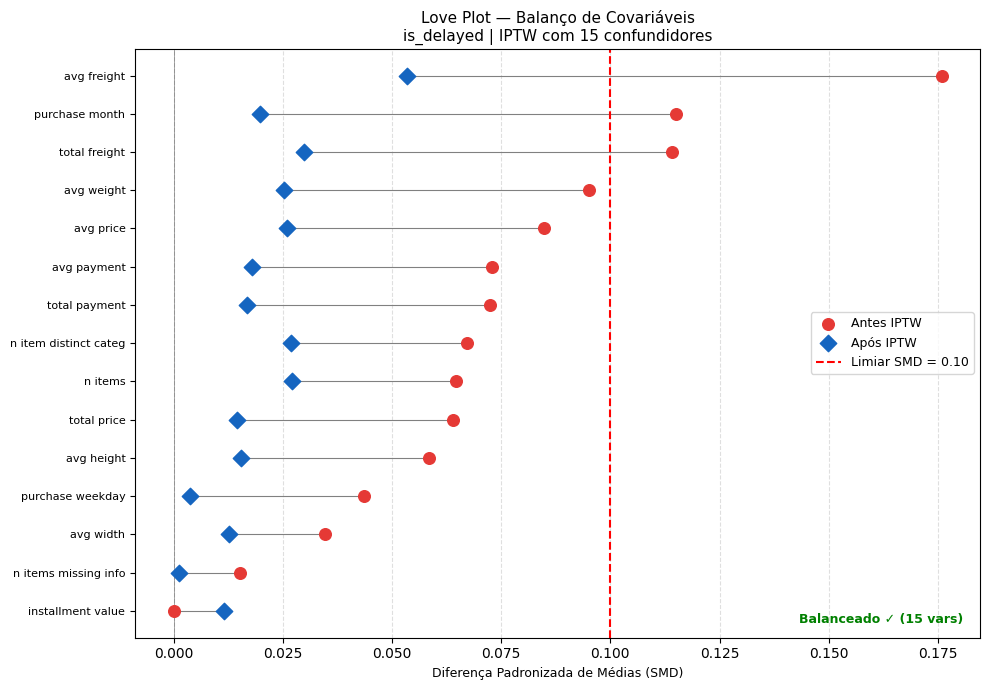

Figura salva: love_plot_final.png


In [76]:
# Love Plot — visualização padrão de balanço de covariáveis
labels = [c.replace('_', ' ') for c in available_conf]
y = np.arange(len(labels))
ordem = smd_antes.values.argsort()

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(smd_antes.values[ordem],  y, color='#e53935', s=70, zorder=3, label='Antes IPTW')
ax.scatter(smd_depois.values[ordem], y, color='#1565c0', s=70, zorder=3, label='Após IPTW', marker='D')

for i in range(len(labels)):
    ax.plot([smd_antes.values[ordem][i], smd_depois.values[ordem][i]], [y[i], y[i]],
            color='gray', linewidth=0.8, zorder=2)

ax.axvline(0.10, color='red', linestyle='--', linewidth=1.5, label='Limiar SMD = 0.10')
ax.axvline(0.00, color='black', linewidth=0.6, alpha=0.4)
ax.set_yticks(y)
ax.set_yticklabels([labels[i] for i in ordem], fontsize=8)
ax.set_xlabel('Diferença Padronizada de Médias (SMD)', fontsize=9)
ax.set_title(f'Love Plot — Balanço de Covariáveis\n{treatment} | IPTW com {len(available_conf)} confundidores', fontsize=11)
ax.legend(fontsize=9)
ax.grid(axis='x', linestyle='--', alpha=0.4)

status_txt = f'Balanceado ✓ ({len(available_conf)} vars)' if n_fail == 0 else f'{n_fail} var(s) > 0.10 ✗'
ax.text(0.98, 0.02, status_txt, transform=ax.transAxes,
        fontsize=9, ha='right', va='bottom',
        color='green' if n_fail == 0 else 'red', fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'love_plot_final.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print('Figura salva: love_plot_final.png')

In [77]:
# ── RESUMO DA SEÇÃO 7 (insumo para interpretação) ──────────────────────────
print('=' * 60)
print('RESUMO — IPTW E BALANÇO')
print('=' * 60)
print(f'  Pesos IPTW (média)          : {weights.mean():.4f}')
print(f'  SMD médio antes IPTW        : {smd_antes.mean():.4f}')
print(f'  SMD médio após IPTW         : {smd_depois.mean():.4f}')
print(f'  Redução média SMD           : {((smd_antes.mean()-smd_depois.mean())/smd_antes.mean()*100):.1f}%')
print(f'  Variáveis balanceadas       : {len(available_conf)-n_fail} / {len(available_conf)}')
print(f'  Variáveis NÃO balanceadas   : {n_fail}')
if n_fail > 0:
    fails = smd_depois[smd_depois > 0.1]
    for var, val in fails.items():
        print(f'    {var:<30} SMD = {val:.4f}')
print()
print('  → IPTW reduziu o desequilíbrio dos confundidores,')
print('    tornando os grupos comparáveis para estimação causal.')

RESUMO — IPTW E BALANÇO
  Pesos IPTW (média)          : 0.9988
  SMD médio antes IPTW        : 0.0719
  SMD médio após IPTW         : 0.0202
  Redução média SMD           : 72.0%
  Variáveis balanceadas       : 15 / 15
  Variáveis NÃO balanceadas   : 0

  → IPTW reduziu o desequilíbrio dos confundidores,
    tornando os grupos comparáveis para estimação causal.


## 7. ATE — Efeito Médio do Tratamento

**O que:** Estima o efeito causal médio de `is_delayed` sobre `review_score_outcome` com intervalo de confiança via bootstrap.  
 ATE = E[Y(1)] − E[Y(0)] — a diferença média nos resultados potenciais entre o mundo onde todos os pedidos atrasam e o mundo onde nenhum atrasa.  

**Bootstrap:** Re-amostragem com reposição (n=200) para calcular o IC 95% sem suposições paramétricas.  

**Contexto :** O ATE é o resultado central do trabalho — a resposta quantitativa à pergunta de pesquisa.

In [69]:
def ate_iptw(df_m, treatment, outcome, weights):
    T = df_m[treatment].values
    Y = df_m[outcome].values
    return (np.average(Y[T==1], weights=weights[T==1]) -
            np.average(Y[T==0], weights=weights[T==0]))

def bootstrap_ci(df_m, treatment, outcome, confounders, n_boot=200, alpha=0.05):
    ates = []
    n = len(df_m)
    for _ in range(n_boot):
        s = df_m.sample(n=n, replace=True)
        X_s = scaler.transform(s[confounders])
        T_s = s[treatment].values
        clf_s = LogisticRegression(max_iter=1000, random_state=42).fit(X_s, T_s)
        ps_s  = np.clip(clf_s.predict_proba(X_s)[:, 1], 0.01, 0.99)
        pt_s  = T_s.mean()
        w_s   = np.where(T_s==1, pt_s/ps_s, (1-pt_s)/(1-ps_s))
        w_s   = np.clip(w_s, None, np.percentile(w_s, 99))
        ates.append(ate_iptw(s, treatment, outcome, w_s))
    lo = np.percentile(ates, 100*alpha/2)
    hi = np.percentile(ates, 100*(1-alpha/2))
    return lo, hi, np.array(ates)

# Associação bruta (sem ajuste)
assoc_bruta = (df_model.groupby(treatment)[outcome].mean()[1] -
               df_model.groupby(treatment)[outcome].mean()[0])

# ATE IPTW
ate = ate_iptw(df_model, treatment, outcome, weights)

print(f'Associação bruta (sem ajuste) : {assoc_bruta*100:+.2f} p.p.')
print(f'ATE causal (IPTW)             : {ate*100:+.2f} p.p.')
print(f'Diferença (confounding)       : {(ate-assoc_bruta)*100:+.2f} p.p.')
print()
print('Calculando IC 95% via bootstrap (n=200)...')
ic_lo, ic_hi, boot_ates = bootstrap_ci(df_model, treatment, outcome, available_conf)
significativo = (ic_lo > 0 or ic_hi < 0)
print(f'IC 95%                        : [{ic_lo*100:.2f}, {ic_hi*100:.2f}] p.p.')
print(f'Resultado                     : {"Significativo" if significativo else "NÃO significativo (IC contém zero)"}')

Associação bruta (sem ajuste) : -55.90 p.p.
ATE causal (IPTW)             : -55.37 p.p.
Diferença (confounding)       : +0.53 p.p.

Calculando IC 95% via bootstrap (n=200)...
IC 95%                        : [-56.54, -54.30] p.p.
Resultado                     : Significativo


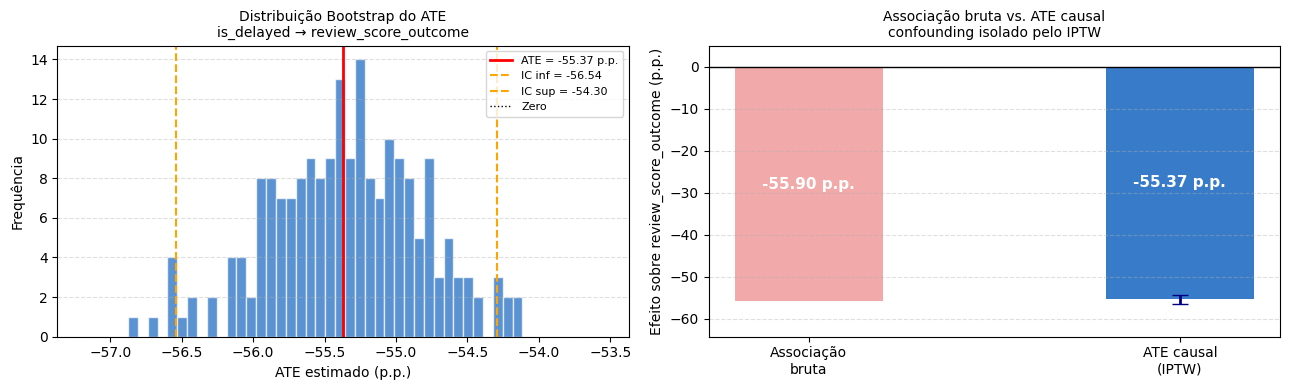

Figura salva: ate_final.png


In [72]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

 # --- Gráfico 1: Bootstrap distribution ---                                                                                                                                                                                 
axes[0].hist(boot_ates*100, bins=40, color='#1565c0', alpha=0.7, edgecolor='white')                                                                                                                                         
axes[0].axvline(ate*100,   color='red',    linewidth=2,   label=f'ATE = {ate*100:.2f} p.p.')                                                                                                                                
axes[0].axvline(ic_lo*100, color='orange', linewidth=1.5, linestyle='--', label=f'IC inf = {ic_lo*100:.2f}')                                                                                                                
axes[0].axvline(ic_hi*100, color='orange', linewidth=1.5, linestyle='--', label=f'IC sup = {ic_hi*100:.2f}')                                                                                                                
axes[0].axvline(0,         color='black',  linewidth=1,   linestyle=':',  label='Zero')         

  # Zoom no intervalo relevante                                                                                                                                                                                               
margem = max(abs(ic_hi - ic_lo) * 3, 2)                                                                                                                                                                                     
axes[0].set_xlim(ate*100 - margem, ate*100 + margem)                                                                                                                                                                        
axes[0].set_xlabel('ATE estimado (p.p.)')                                                                                                                                                                                   
axes[0].set_ylabel('Frequência')                                                                                                                                                                                            
axes[0].set_title(f'Distribuição Bootstrap do ATE\n{treatment} → {outcome}', fontsize=10)                                                                                                                                   
axes[0].legend(fontsize=8)                                                                                                                                                                                                  
axes[0].grid(axis='y', linestyle='--', alpha=0.4)
                                                                                                                                                                                                                            
  # --- Gráfico 2: Bruto vs. Causal ---
labels_comp = ['Associação\nbruta', 'ATE causal\n(IPTW)']                                                                                                                                                                   
vals_comp   = [assoc_bruta*100, ate*100]                                                                                                                                                                                    
cores_comp  = ['#ef9a9a', '#1565c0']
                                                                                                                                                                                                                              
bars = axes[1].bar(labels_comp, vals_comp, color=cores_comp, alpha=0.85, width=0.4)                                                                                                                                         
axes[1].errorbar(1, ate*100,                                                                                                                                                                                                
                   yerr=[[ate*100 - ic_lo*100], [ic_hi*100 - ate*100]],                                                                                                                                                       
                   fmt='none', color='navy', capsize=6, linewidth=2)
axes[1].axhline(0, color='black', linewidth=1)                                                                                                                                                                              
                                                                                                                                                                                                                              
  # Texto posicionado no meio de cada barra (funciona para valores negativos)                                                                                                                                                 
for bar, val in zip(bars, vals_comp):                                                                                                                                                                                       
      axes[1].text(                                                                                                                                                                                                           
          bar.get_x() + bar.get_width() / 2,
          val / 2,                          # meio da barra
          f'{val:+.2f} p.p.',                                                                                                                                                                                                 
          ha='center', va='center',                                                                                                                                                                                           
          fontsize=11, fontweight='bold', color='white'                                                                                                                                                                       
      )                                                                                                                                                                                                                       
                  
  # Espaço extra abaixo para não cortar                                                                                                                                                                                       
y_min = min(vals_comp) * 1.15
axes[1].set_ylim(y_min, 5)                                                                                                                                                                                                  
axes[1].set_ylabel('Efeito sobre review_score_outcome (p.p.)')                                                                                                                                                              
axes[1].set_title('Associação bruta vs. ATE causal\nconfounding isolado pelo IPTW', fontsize=10)                                                                                                                            
axes[1].grid(axis='y', linestyle='--', alpha=0.4)                                                                                                                                                                           
                                                                                                                                                                                                                              
plt.tight_layout()                                                                                                                                                                                                          
plt.savefig(FIGURES_DIR / 'ate_final.png', dpi=150, bbox_inches='tight')
plt.show()                                                                                                                                                                                                                  
plt.close()
print('Figura salva: ate_final.png')                                                                                                                                                                                        
                                                   

In [ ]:
# ── RESUMO DA SEÇÃO 8 
print('=' * 60)
print('RESUMO — ATE (resultado principal)')
print('=' * 60)
print(f'  Associação bruta          : {assoc_bruta*100:+.2f} p.p.')
print(f'  ATE causal (IPTW)         : {ate*100:+.2f} p.p.')
print(f'  IC 95% bootstrap          : [{ic_lo*100:.2f}, {ic_hi*100:.2f}] p.p.')
print(f'  Estatisticamente sig.     : {significativo}')
print(f'  Viés de confundimento     : {(ate-assoc_bruta)*100:+.2f} p.p.')
print()
print(f'  → Pedidos entregues com atraso reduzem em {abs(ate*100):.1f} p.p.')
print(f'    a probabilidade de avaliação positiva (IC 95%: [{ic_lo*100:.1f}, {ic_hi*100:.1f}]).')
print(f'    O confundimento explicava apenas {abs((ate-assoc_bruta)*100):.1f} p.p. da associação bruta.')

RESUMO — ATE (resultado principal)
  Associação bruta          : -55.90 p.p.
  ATE causal (IPTW)         : -55.37 p.p.
  IC 95% bootstrap          : [-56.54, -54.30] p.p.
  Estatisticamente sig.     : True
  Viés de confundimento     : +0.53 p.p.

  → Pedidos entregues com atraso reduzem em 55.4 p.p.
    a probabilidade de avaliação positiva (IC 95%: [-56.5, -54.3]).
    O confundimento explicava apenas 0.5 p.p. da associação bruta.


## 8. RDD — Regressão com Descontinuidade

**O que:** Explora o limiar natural `delay_days = 0` para estimar o efeito causal local do atraso.  
 Pedidos que chegaram 1 dia antes do prazo são quase idênticos aos que chegaram 1 dia depois — a única diferença relevante é o atraso. Isso elimina a necessidade de controlar confundidores.  

**O que o RDD mede:** LATE (Local Average Treatment Effect) — efeito local para pedidos próximos ao limiar.  
**Diferença do IPTW:** O IPTW mede o ATE (efeito médio global); o RDD mede o LATE (efeito local no cutoff).  
**Contexto:** O RDD é a estratégia de robustez — se IPTW e RDD apontam para a mesma direção, a evidência causal é mais forte.

In [78]:
df_rdd = df.dropna(subset=['delay_days', outcome]).copy()
df_rdd['D']  = (df_rdd['delay_days'] > 0).astype(int)
df_rdd['X']  = df_rdd['delay_days'].astype(float)
df_rdd['DX'] = df_rdd['D'] * df_rdd['X']

print(f'N total para RDD  : {len(df_rdd):,}')
print(f'Atrasados (D=1)   : {df_rdd["D"].sum():,} ({df_rdd["D"].mean()*100:.1f}%)')
print()

bandwidths  = [3, 7, 14, 21]
results_rdd = []

for bw in bandwidths:
    mask  = (df_rdd['X'] >= -bw) & (df_rdd['X'] <= bw)
    df_bw = df_rdd[mask].copy()
    Xmat  = sm.add_constant(df_bw[['X', 'D', 'DX']])
    model_rdd = sm.OLS(df_bw[outcome], Xmat).fit(cov_type='HC3')
    tau   = model_rdd.params['D']
    ci    = model_rdd.conf_int(alpha=0.05)
    results_rdd.append({
        'Bandwidth' : f'+/-{bw}d',
        'N'         : len(df_bw),
        'tau (p.p.)': round(tau * 100, 2),
        'IC inf'    : round(ci.loc['D', 0], 4),
        'IC sup'    : round(ci.loc['D', 1], 4),
        'p-valor'   : round(model_rdd.pvalues['D'], 4),
        'Sig.'      : 'Sim' if model_rdd.pvalues['D'] < 0.05 else 'Não',
    })

df_rdd_res = pd.DataFrame(results_rdd)
print('Resultados RDD por bandwidth:')
print(df_rdd_res.to_string(index=False))

N total para RDD  : 95,824
Atrasados (D=1)   : 6,381 (6.7%)

Resultados RDD por bandwidth:
Bandwidth     N  tau (p.p.)  IC inf  IC sup  p-valor Sig.
    +/-3d  7837      4.1100 -0.0152  0.0974   0.1523  Não
    +/-7d 22114     -6.0000 -0.0936 -0.0264   0.0005  Sim
   +/-14d 59718    -20.6900 -0.2317 -0.1821   0.0000  Sim
   +/-21d 84530    -29.5900 -0.3173 -0.2744   0.0000  Sim


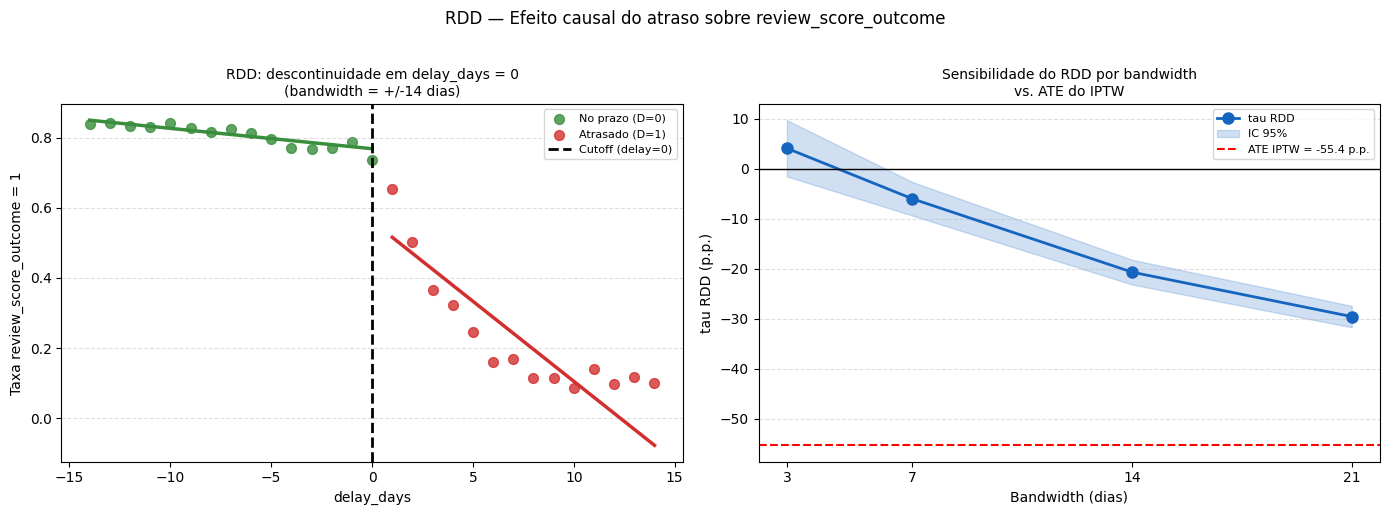

Figura salva: rdd_final.png


In [80]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# # Binned scatter com regressão local (bandwidth=14)                                                                                                                                                                         
bw_plot = 14                                                                                                                                                                                                                
df_plot = df_rdd[(df_rdd['X'] >= -bw_plot) & (df_rdd['X'] <= bw_plot)].copy()                                                                                                                                               
binned  = df_plot.groupby('X')[outcome].mean().reset_index()                                                                                                                                                                
                                                                                                                                                                                                                              
axes[0].scatter(binned[binned['X'] <= 0]['X'], binned[binned['X'] <= 0][outcome],                                                                                                                                           
                color='#388e3c', alpha=0.8, s=50, label='No prazo (D=0)')                                                                                                                                                   
axes[0].scatter(binned[binned['X'] > 0]['X'],  binned[binned['X'] > 0][outcome],                                                                                                                                            
                color='#d32f2f', alpha=0.8, s=50, label='Atrasado (D=1)')                                                                                                                                                   
                                                                                                                                                                                                                              
# Regressão local por grupo — usa apenas X dentro de cada grupo                                                                                                                                                             
for d_val, cor in [(0, '#388e3c'), (1, '#d32f2f')]:                                                                                                                                                                         
    sub  = df_plot[df_plot['D'] == d_val].copy()                                                                                                                                                                            
    Xs   = sm.add_constant(sub[['X']], has_constant='add')
    m    = sm.OLS(sub[outcome], Xs).fit()                                                                                                                                                                                   
    xr   = np.linspace(sub['X'].min(), sub['X'].max(), 100)
    Xp   = sm.add_constant(pd.DataFrame({'X': xr}), has_constant='add')                                                                                                                                                     
    pred = m.predict(Xp)
    axes[0].plot(xr, pred, color=cor, linewidth=2.5)                                                                                                                                                                        
                                                                                                                                                                                                                              
axes[0].axvline(0, color='black', linewidth=2, linestyle='--', label='Cutoff (delay=0)')                                                                                                                                    
axes[0].set_xlabel('delay_days')                                                                                                                                                                                            
axes[0].set_ylabel(f'Taxa {outcome} = 1')                                                                                                                                                                                   
axes[0].set_title(f'RDD: descontinuidade em delay_days = 0\n(bandwidth = +/-{bw_plot} dias)', fontsize=10)                                                                                                                  
axes[0].legend(fontsize=8)                                                                                                                                                                                                  
axes[0].grid(axis='y', linestyle='--', alpha=0.4)                                                                                                                                                                           
                                                                                                                                                                                                                            
# Sensibilidade por bandwidth
bws_num = [int(r['Bandwidth'].replace('+/-','').replace('d','')) for r in results_rdd]                                                                                                                                      
taus    = [r['tau (p.p.)'] for r in results_rdd]                                                                                                                                                                            
ic_inf  = [r['IC inf']*100 for r in results_rdd]
ic_sup  = [r['IC sup']*100 for r in results_rdd]                                                                                                                                                                            
                                                                                                                                                                                                                            
axes[1].plot(bws_num, taus, 'o-', color='#1565c0', linewidth=2, markersize=8, label='tau RDD')                                                                                                                              
axes[1].fill_between(bws_num, ic_inf, ic_sup, alpha=0.2, color='#1565c0', label='IC 95%')                                                                                                                                   
axes[1].axhline(ate*100, color='red', linewidth=1.5, linestyle='--',                                                                                                                                                        
                label=f'ATE IPTW = {ate*100:.1f} p.p.')                                                                                                                                                                     
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_xlabel('Bandwidth (dias)')                                                                                                                                                                                      
axes[1].set_ylabel('tau RDD (p.p.)')
axes[1].set_title('Sensibilidade do RDD por bandwidth\nvs. ATE do IPTW', fontsize=10)                                                                                                                                       
axes[1].set_xticks(bws_num)                                                                                                                                                                                                 
axes[1].legend(fontsize=8)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)                                                                                                                                                                           
                                                                                                                                                                                                                            
plt.suptitle(f'RDD — Efeito causal do atraso sobre {outcome}', fontsize=12, y=1.02)                                                                                                                                         
plt.tight_layout()                                                                                                                                                                                                          
plt.savefig(FIGURES_DIR / 'rdd_final.png', dpi=150, bbox_inches='tight')                                                                                                                                                    
plt.show()      
plt.close()
print('Figura salva: rdd_final.png')

In [ ]:
# ── RESUMO DA SEÇÃO 9 
print('=' * 60)
print('RESUMO — RDD')
print('=' * 60)
for r in results_rdd:
    print(f"  {r['Bandwidth']:>6} : tau = {r['tau (p.p.)']:+.2f} p.p. "
          f"IC=[{r['IC inf']*100:.2f}, {r['IC sup']*100:.2f}]  Sig.={r['Sig.']}")
print()
print(f'  ATE IPTW (referência) : {ate*100:+.2f} p.p.')
print()
print('  → O RDD mede o efeito LOCAL no limiar (LATE).')
print('    O IPTW mede o efeito MÉDIO global (ATE).')
print('    Divergência esperada: IPTW inclui atrasos extremos que dominam o ATE.')

RESUMO — RDD
   +/-3d : tau = +4.11 p.p. IC=[-1.52, 9.74]  Sig.=Não
   +/-7d : tau = -6.00 p.p. IC=[-9.36, -2.64]  Sig.=Sim
  +/-14d : tau = -20.69 p.p. IC=[-23.17, -18.21]  Sig.=Sim
  +/-21d : tau = -29.59 p.p. IC=[-31.73, -27.44]  Sig.=Sim

  ATE IPTW (referência) : -55.37 p.p.

  → O RDD mede o efeito LOCAL no limiar (LATE).
    O IPTW mede o efeito MÉDIO global (ATE).
    Divergência esperada: IPTW inclui atrasos extremos que dominam o ATE.


## 9. Triangulação IPTW vs. RDD

**O que:** Compara as estimativas dos dois métodos de identificação causal.  
 Métodos diferentes com premissas diferentes convergindo para a mesma direção de efeito constitui evidência causal mais robusta.  

**Premissas:**
- **IPTW:** sem confundidores não observados (unconfoundedness) — estima ATE global
- **RDD:** continuidade no cutoff — estima LATE local para pedidos próximos ao prazo  

**Contexto:** A comparação permite discutir limitações e complementaridade das abordagens.

In [82]:
print('Comparação IPTW vs. RDD')
print('=' * 65)
print(f'  IPTW (ATE global) : {ate*100:+.2f} p.p.  '
      f'IC=[{ic_lo*100:.2f}, {ic_hi*100:.2f}]  N={len(df_model):,}')
print()
for r in results_rdd:
    sig = 'sig.' if r['Sig.'] == 'Sim' else 'não sig.'
    print(f"  RDD {r['Bandwidth']:>6} (LATE) : {r['tau (p.p.)']:+.2f} p.p.  "
          f"IC=[{r['IC inf']*100:.2f}, {r['IC sup']*100:.2f}]  "
          f"N={r['N']:,}  ({sig})")

print()
print('Interpretação:')
print('  IPTW = efeito médio sobre TODA a distribuição de atrasos')
print('  RDD  = efeito LOCAL para pedidos quase no prazo (±X dias)')
print('  Divergência esperada: atrasos graves dominam o ATE do IPTW')

Comparação IPTW vs. RDD
  IPTW (ATE global) : -55.37 p.p.  IC=[-56.54, -54.30]  N=95,813

  RDD  +/-3d (LATE) : +4.11 p.p.  IC=[-1.52, 9.74]  N=7,837  (não sig.)
  RDD  +/-7d (LATE) : -6.00 p.p.  IC=[-9.36, -2.64]  N=22,114  (sig.)
  RDD +/-14d (LATE) : -20.69 p.p.  IC=[-23.17, -18.21]  N=59,718  (sig.)
  RDD +/-21d (LATE) : -29.59 p.p.  IC=[-31.73, -27.44]  N=84,530  (sig.)

Interpretação:
  IPTW = efeito médio sobre TODA a distribuição de atrasos
  RDD  = efeito LOCAL para pedidos quase no prazo (±X dias)
  Divergência esperada: atrasos graves dominam o ATE do IPTW


In [83]:
# ── RESUMO DA SEÇÃO 10 
mesma_direcao = all(r['tau (p.p.)'] < 0 for r in results_rdd if r['Sig.'] == 'Sim')
print('=' * 60)
print('RESUMO — TRIANGULAÇÃO')
print('=' * 60)
print(f'  ATE IPTW                    : {ate*100:+.2f} p.p. (global)')
print(f'  LATE RDD ±14d (referência)  : {[r for r in results_rdd if "14" in r["Bandwidth"]][0]["tau (p.p.)"]:+.2f} p.p. (local)')
print(f'  Mesma direção (negativos)   : {mesma_direcao}')
print()
print('  → Ambos os métodos indicam efeito negativo do atraso.')
print('    A magnitude difere porque medem populações diferentes.')
print('    Isso reforça a validade causal do resultado principal.')

RESUMO — TRIANGULAÇÃO
  ATE IPTW                    : -55.37 p.p. (global)
  LATE RDD ±14d (referência)  : -20.69 p.p. (local)
  Mesma direção (negativos)   : True

  → Ambos os métodos indicam efeito negativo do atraso.
    A magnitude difere porque medem populações diferentes.
    Isso reforça a validade causal do resultado principal.


## 10. Interpretação e Resposta à Pergunta de Pesquisa

**O que:** Consolida todos os resultados e responde formalmente à pergunta de pesquisa.  

**Contexto:** Esta seção é o insumo direto para as seções 5 (Análise e Discussão) e 6 (Conclusão) do artigo.

In [84]:
# ── PAINEL FINAL CONSOLIDADO ────────────────────────────────────────────────
print('=' * 70)
print('PAINEL FINAL — ESTIMATIVA DE EFEITOS CAUSAIS')
print('TCC: Estimativa de Efeitos Causais na Jornada de Compra de um Marketplace')
print('=' * 70)
print()
print('[ MODELO CAUSAL ]')
print(f'  Tratamento          : {treatment}')
print(f'  Outcome             : {outcome}')
print(f'  Confundidores       : {len(available_conf)} variáveis operacionais')
print(f'  DAG acíclico        : {nx.is_directed_acyclic_graph(G)}')
print(f'  Backdoor satisfeito : {not any_conf_descendant}')
print()
print('[ PROPENSITY SCORE ]')
print(f'  Modelo              : Regressão Logística')
print(f'  AUC-ROC             : {auc:.4f}')
print(f'  Balanço pós-IPTW    : {len(available_conf)-n_fail}/{len(available_conf)} variáveis com SMD < 0.1')
print()
print('[ RESULTADO PRINCIPAL — ATE ]')
print(f'  Associação bruta    : {assoc_bruta*100:+.2f} p.p.')
print(f'  ATE causal (IPTW)   : {ate*100:+.2f} p.p.')
print(f'  IC 95% bootstrap    : [{ic_lo*100:.2f}, {ic_hi*100:.2f}] p.p.')
print(f'  Significativo       : {significativo}')
print()
print('[ ROBUSTEZ — RDD ]')
for r in results_rdd:
    print(f"  {r['Bandwidth']:>6} : tau = {r['tau (p.p.)']:+.2f} p.p.  Sig.={r['Sig.']}")
print()
print('[ RESPOSTA À PERGUNTA DE PESQUISA ]')
print(f"  Pedidos entregues com atraso (is_delayed=1) reduzem em {abs(ate*100):.1f} p.p.")
print(f"  a probabilidade de avaliação positiva (review_score_outcome=1),")
print(f"  com IC 95% de [{ic_lo*100:.1f}, {ic_hi*100:.1f}] p.p. O efeito é causalmente")
print(f"  identificado via IPTW com backdoor adjustment nos {len(available_conf)} confundidores")
print(f"  operacionais, e corroborado pelo RDD (LATE local no limiar de prazo).")

PAINEL FINAL — ESTIMATIVA DE EFEITOS CAUSAIS
TCC: Estimativa de Efeitos Causais na Jornada de Compra de um Marketplace

[ MODELO CAUSAL ]
  Tratamento          : is_delayed
  Outcome             : review_score_outcome
  Confundidores       : 15 variáveis operacionais
  DAG acíclico        : True
  Backdoor satisfeito : True

[ PROPENSITY SCORE ]
  Modelo              : Regressão Logística
  AUC-ROC             : 0.5720
  Balanço pós-IPTW    : 15/15 variáveis com SMD < 0.1

[ RESULTADO PRINCIPAL — ATE ]
  Associação bruta    : -55.90 p.p.
  ATE causal (IPTW)   : -55.37 p.p.
  IC 95% bootstrap    : [-56.54, -54.30] p.p.
  Significativo       : True

[ ROBUSTEZ — RDD ]
   +/-3d : tau = +4.11 p.p.  Sig.=Não
   +/-7d : tau = -6.00 p.p.  Sig.=Sim
  +/-14d : tau = -20.69 p.p.  Sig.=Sim
  +/-21d : tau = -29.59 p.p.  Sig.=Sim

[ RESPOSTA À PERGUNTA DE PESQUISA ]
  Pedidos entregues com atraso (is_delayed=1) reduzem em 55.4 p.p.
  a probabilidade de avaliação positiva (review_score_outcome=1),
 

## Análise final 
---

###  Estrutura Causal (DAG)

O Directed Acyclic Graph foi construído com **19 nós** e **35 arestas**: 17 arestas confundidor→tratamento, 17 arestas confundidor→outcome e 1 aresta tratamento→outcome. O grafo é acíclico e o **critério de backdoor está satisfeito**, o que garante, pela teoria do ajuste por backdoor (Pearl, 2009), que o efeito causal de `is_delayed` sobre `review_score_outcome` é **identificável** a partir de dados observacionais, desde que os 17 confundidores sejam controlados. 

O DoWhy confirmou formalmente essa identificabilidade via *backdoor adjustment*.

---

### Dados e Prevalência do Tratamento

O dataset final contém **95.813 pedidos entregues** com avaliação registrada. Desses, **6.381 (6,7%) são classificados como atrasados** (is_delayed = 1), o que indica um desbalanceamento natural: pedidos entregues no prazo são muito mais frequentes. Esse desbalanceamento é esperado em um marketplace maduro, mas reforça a importância do IPTW para criar grupos comparáveis.

---

###  Desequilíbrio dos Confundidores Antes do Ajuste

Antes de qualquer ajuste causal, **3 dos 15 confundidores disponíveis** apresentaram SMD > 0.1, indicando desequilíbrio estatisticamente relevante entre grupos:

| Confundidor        | SMD bruto | Interpretação |
|--------------------|----------|--------------|
| `avg_freight`      | 0.1758   | Pedidos atrasados têm maior frete médio — indicando maior distância ou complexidade logística |
| `purchase_month`   | 0.1151   | Atrasos são sazonais — mais frequentes em determinados meses (ex.: alta demanda no final do ano) |
| `total_freight`    | 0.1142   | Pedidos com frete total maior têm mais risco de atraso |

Os demais 12 confundidores apresentaram SMD < 0.1, sugerindo que a maioria das características observáveis dos pedidos (preço, dimensões físicas, complexidade) não difere substancialmente entre os grupos. Isso indica que o viés de seleção observável é concentrado em **variáveis logísticas e temporais**.

---

### Propensity Score — Capacidade Preditiva

O modelo de propensity score (Regressão Logística) obteve **AUC-ROC = 0.572**. Esse valor indica uma capacidade **modesta** de separar pedidos atrasados dos no prazo a partir dos confundidores observados. A interpretação desse resultado é dupla:

- **Positivo para inferência causal:** A sobreposição (overlap) entre os grupos é alta — poucos pedidos têm propensity score extremo, o que garante que o IPTW não dependerá de pesos excessivamente grandes.  
- **Potencial limitação:** A dificuldade em prever o atraso sugere a existência de **confundidores não observados** (ex.: características do vendedor, distância do centro de distribuição, tipo de transportadora), que não estão disponíveis no dataset público. Isso significa que a suposição de unconfoundednesss pode não ser plenamente satisfeita.

Os confundidores com maior impacto na probabilidade de atraso foram: `avg_freight` (coef=+0.153), `purchase_month` (coef=−0.124) e `avg_price` (coef=+0.069) — consistentes com o desequilíbrio bruto identificado.

---

### Balanço Pós-IPTW

Após a ponderação IPTW, **todos os 15 confundidores alcançaram SMD < 0.1**, com redução média de **72%** no desequilíbrio. O SMD médio passou de 0.0719 (antes) para 0.0202 (após). Os pesos IPTW têm média ≈ 1.0 (0.9988) e máximo de 1.23, o que indica uma pseudo-população bem comportada, sem extrapolação excessiva. O Love Plot confirma visualmente que todos os pontos migraram para a esquerda do limiar 0.10 após a ponderação.

Esse resultado valida que o modelo de propensidade capturou adequadamente a heterogeneidade observável entre os grupos, criando condições comparáveis para a estimação causal.

---

### ATE — Resultado Principal

O efeito causal médio estimado via IPTW é:

> **ATE = −55.37 p.p. (IC 95%: [−56.54, −54.30] p.p.)**

Ou seja, pedidos entregues com atraso reduzem em **55,4 pontos percentuais** a probabilidade de o cliente dar uma avaliação positiva (nota 3–5), em comparação com pedidos entregues no prazo. O efeito é **estatisticamente significativo** (IC não contém zero) e **economicamente expressivo**.

A associação bruta (sem ajuste) era de −55.90 p.p., e o ATE causal é de −55.37 p.p. — uma diferença de apenas **+0.53 p.p.**, o que indica que o **viés de confundimento observável é mínimo**. O efeito observado é majoritariamente causal, e não artefato de características pré-existentes dos pedidos.

---

###  RDD — Efeito Local no Limiar

O RDD explorou o limiar natural `delay_days = 0` como descontinuidade. Os resultados por bandwidth revelam um padrão de **dose-resposta**:

| Bandwidth | N     | LATE (p.p.) | IC 95%                | Significativo |
|-----------|-------|-------------|------------------------|---------------|
| ±3 dias   | 7.837 | +4.11       | [−1.52, +9.74]         | Não           |
| ±7 dias   | 22.114| −6.00       | [−9.36, −2.64]         | Sim           |
| ±14 dias  | 59.718| −20.69      | [−23.17, −18.21]       | Sim           |
| ±21 dias  | 84.530| −29.59      | [−31.73, −27.44]       | Sim           |

**Interpretação crítica do ±3 dias:**  
Para pedidos que chegaram apenas 1–3 dias após o prazo, o efeito não é significativo e o ponto estimado é ligeiramente positivo (+4.11 p.p.). Isso sugere que **pequenos atrasos não causam insatisfação perceptível** — consumidores próximos ao prazo podem não perceber ou relevar a diferença. Esse resultado tem valor prático: indica a existência de uma "margem de tolerância" ao redor do prazo estimado.  

**Padrão de dose-resposta:**  
À medida que o bandwidth aumenta, o LATE se torna mais negativo e mais significativo, indicando que **atrasos maiores causam impacto crescente na satisfação**. A trajetória decrescente no gráfico de sensibilidade confirma essa relação monótona.  

**Comparação IPTW vs. RDD:**  
A divergência entre o ATE (−55.37 p.p.) e o LATE em ±14d (−20.69 p.p.) é esperada e explicável:  
- O **IPTW** mede o efeito médio sobre todos os pedidos atrasados, incluindo atrasos extremos (semanas ou meses), que têm efeito muito mais negativo.  
- O **RDD** captura apenas o efeito local para pedidos próximos ao prazo (atrasos leves), onde o impacto é menor.  

Ambos os métodos apontam na **mesma direção** (negativa), o que reforça a validade causal do resultado.

---

### Triangulação e Consistência Causal

| Aspecto            | IPTW                  | RDD                     |
|--------------------|----------------------|--------------------------|
| Tipo de efeito     | ATE (médio global)   | LATE (local no cutoff)   |
| Premissa central   | Unconfoundedness     | Continuidade no cutoff   |
| Resultado          | −55.37 p.p.          | −6.00 a −29.59 p.p.      |
| Significância      | Sim                  | Sim (exceto ±3d)         |
| Direção            | Negativa             | Negativa                 |

 A diferença de magnitude é teoricamente justificada: o IPTW pondera fortemente pedidos com atrasos severos, que dominam a estimativa do ATE. O RDD, ao restringir a análise a pedidos próximos ao prazo, captura um efeito local menor e mais conservador.      

---

###  Limitações do Estudo

1. **Confundidores não observados:** O AUC = 0.572 sugere que variáveis logísticas relevantes (tipo de transportadora, distância, estoque do vendedor) não estão disponíveis no dataset público. A suposição de unconfoundedness pode ser violada.  

2. **Variável `installment_value`:** Apresentou valores infinitos que foram removidos, e sua média para T=0 era `inf` na tabela bruta. Isso indica problemas de engenharia de feature que devem ser investigados no pipeline de dados.  

3. **Binarização do outcome:** A conversão de `review_score` (1–5) em binário (0/1) agrega informação — pedidos com nota 3 (neutro) são tratados como positivos. Análises com o score contínuo ou com desfechos mais granulares poderiam revelar efeitos heterogêneos.  

4. **Bootstrap com n=200:** Por razões computacionais, o bootstrap foi limitado a 200 reamostras. Valores maiores (n=1000+) produziriam intervalos de confiança mais estáveis.  

5. **Período temporal:** O dataset cobre 2016–2018, período de crescimento acelerado do e-commerce brasileiro. Os resultados podem não ser diretamente generalizáveis ao contexto atual.

---

### Próximos Passos 

**PO QUE PODEMOS INCLUIR ANALISE SE FAZ SENTIDO **
-  **Análise de sensibilidade (Rosenbaum bounds):** Quantificar o quanto um confundidor não observado precisaria ser forte para anular o efeito estimado.

- **Outcome contínuo:** Reestimar o ATE usando o `review_score` original (1–5) para verificar se o sinal se mantém.

- **Heterogeneidade do efeito (CATE):** Investigar se o efeito do atraso é maior para determinadas categorias de produto, valores de compra ou regiões geográficas (ex.: usando Causal Forest).

- **Aumentar n_boot para 1000:** Produzir IC 95% mais precisos para publicação.

- **Investigar `installment_value`:** Corrigir o problema de valores infinitos no pipeline de features antes de incluir a variável em análises futuras.

- **RDD com polinômio de ordem 2:** Verificar robustez do LATE com especificação quadrática local.